In [ ]:
Sfrom google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import sys
!{sys.executable} -m pip install fastdtw

In [ ]:
!pip install flask pyngrok --ignore-installed blinker

  Using cached flask-3.1.2-py3-none-any.whl.metadata (3.2 kB)
  Using cached pyngrok-7.5.0-py3-none-any.whl.metadata (8.1 kB)
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached itsdangerous-2.2.0-py3-none-any.whl.metadata (1.9 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached markupsafe-3.0.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (2.7 kB)
  Using cached werkzeug-3.1.4-py3-none-any.whl.metadata (4.0 kB)
  Using cached pyyaml-6.0.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (2.4 kB)
Using cached flask-3.1.2-py3-none-any.whl (103 kB)
Using cached pyngrok-7.5.0-py3-none-any.whl (24 kB)
Using cached blinker-1.9.0-py3-none-any.whl (8.5 kB)
Using cached click-8.3.1-py3-none-any.whl (108 kB)
Using cached itsdangerous-2.2.0-py3-none-any.whl (16 kB)
Using cached jinja2-3.1.6-py3

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

section_dict = {}

for i in range (1, 5):
  section_dict[i] = list()

# gestures = ["shake-imu", "nod-imu", "lip-puller-imu", "tilt-imu", "mouth-stretch-imu"] # need to explore other gestures based on their graphs
# gestures = ["shake-imu", "nod-imu", "lip-puller-imu", "tilt-imu"] # need to explore other gestures based on their graphs
gestures_old = ["shake-imu", "nod-imu", "tilt-imu"]
def scale_columns(df): # here we scale the columns of the accelerometer data by multiplying it by a factor of 0.061
  for col in df.columns:
    if col.startswith('a'):
      df[col] = (df[col] * 0.061)/1000
    if col.startswith('g'):
      df[col] = (df[col])/1000

  return df

root_location = "/content/drive/MyDrive/Wireless project/P"
for i in range(1,5):
  if (i == 2):
    continue
  for files in os.listdir(root_location + str(i)):
    if (files[2:len(files)-9] not in gestures_old and files[3: len(files)-9] not in gestures_old):
      continue
    if files.endswith("right.csv"):
      continue
    df = pd.read_csv(os.path.join(root_location + str(i), files))
    #apply scaling here for simplicity
    df = df.pipe(scale_columns)
    df_sorted = df.sort_values(by='timestamp')
    df = df_sorted.reset_index(drop=True) # when sorting of data frame happens in previous lines based on the timestamp the order of the old dataframe will be changed, it will become 5,1, 2, 4 etc. we reset the index with reset_index=True and then say drop=True so that the old index is dropped and the new one is adopted
    if (i> 0 and i< 10):
      section_dict[i].append((df, files[2:len(files)-9]))
    else:
      section_dict[i].append((df, files[3:len(files)-9]))


In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt


In [ ]:
section_dict_new = {}
for i in range(0,10):
  section_dict_new[i] = list()

def scale_columns(df):
  for col in df.columns:
    if col.startswith('timestamp'):
      df[col] = df[col].astype(int)
  return df


# gestures = ["shake", "nod", "Tilt", "lip"] #Custom2
gestures = ["SHAKE", "NOD", "TILT", "LIP_PULLER"] #Custom1
root_location_json = "/content/drive/MyDrive/Data/CUSTOM"

for gesture in gestures:
  idx = 0
  for files in os.listdir(root_location_json + "/" + gesture):
    if idx == 10:
      break
    last_underscore = files.rfind('_')
    df_new = pd.read_json(os.path.join(root_location_json + "/" + gesture, files))
    df_new = df_new.pipe(scale_columns)
    df_sorted_new = df_new.sort_values(by='timestamp')
    section_dict_new[idx].append((df_sorted_new, files[:last_underscore]))
    idx += 1

# print(section_dict_new)
# section_dict_new[0][1]




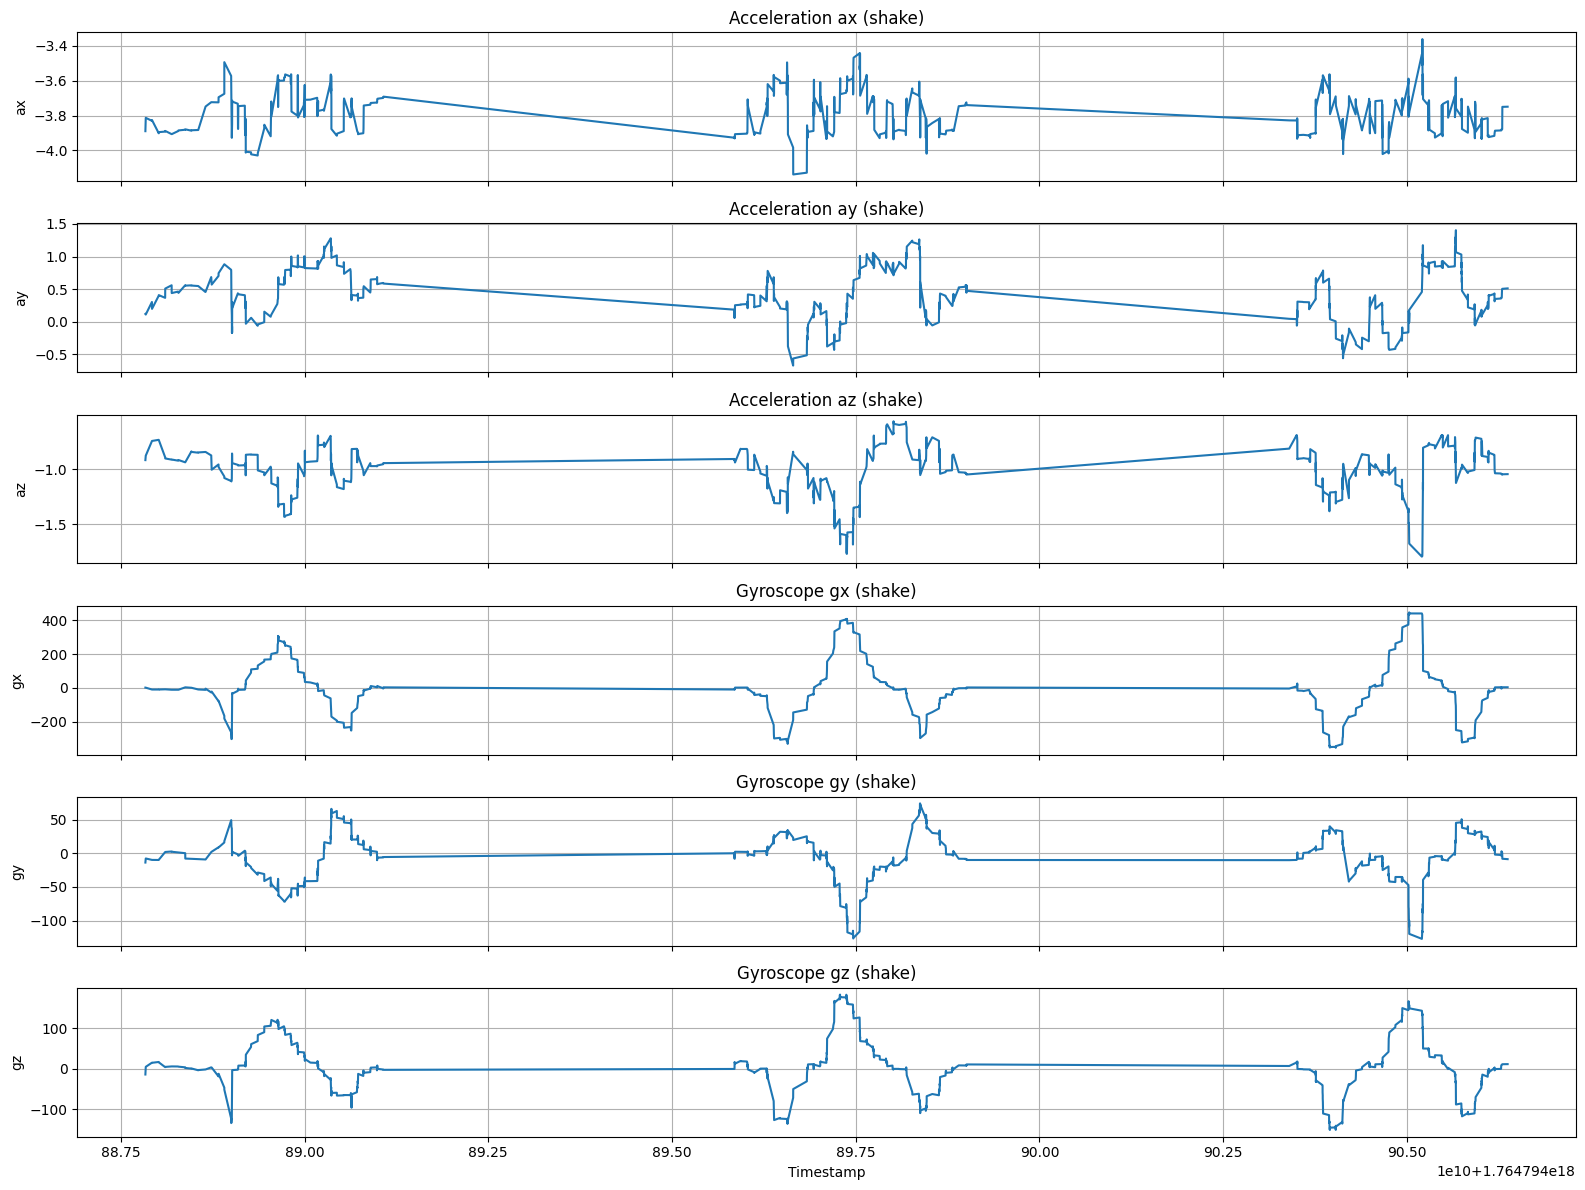

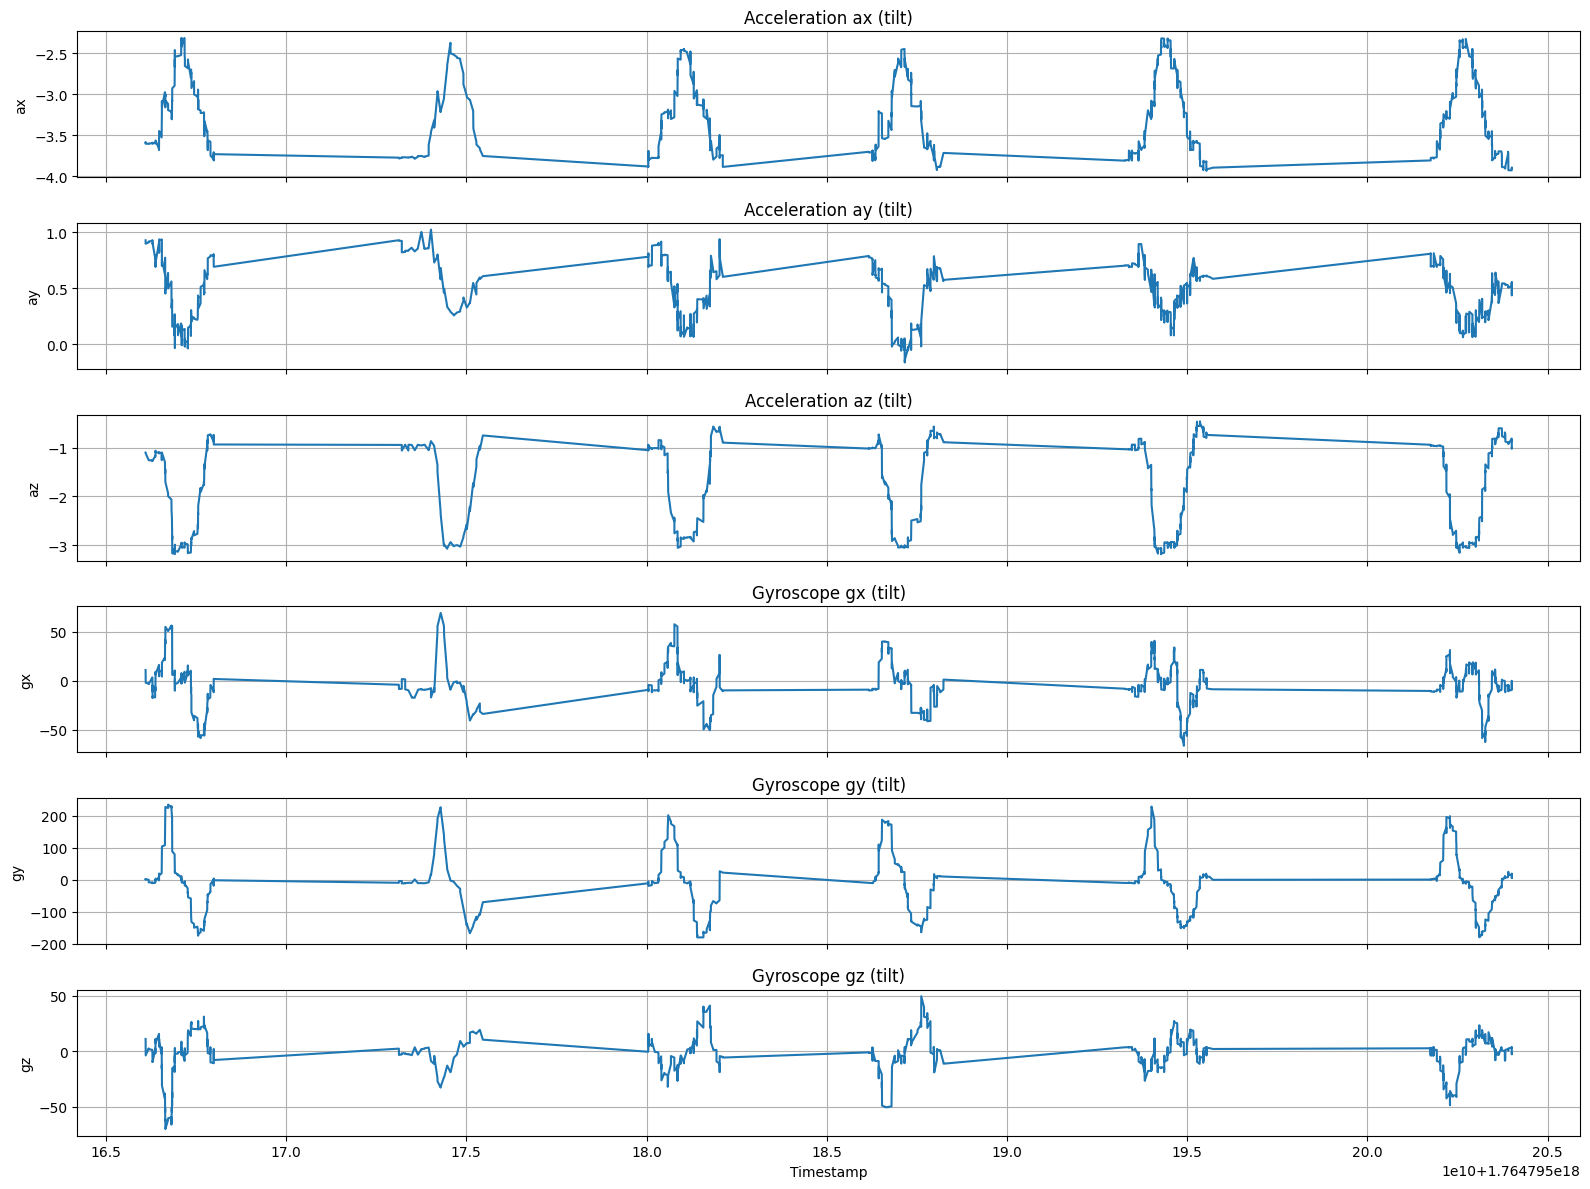

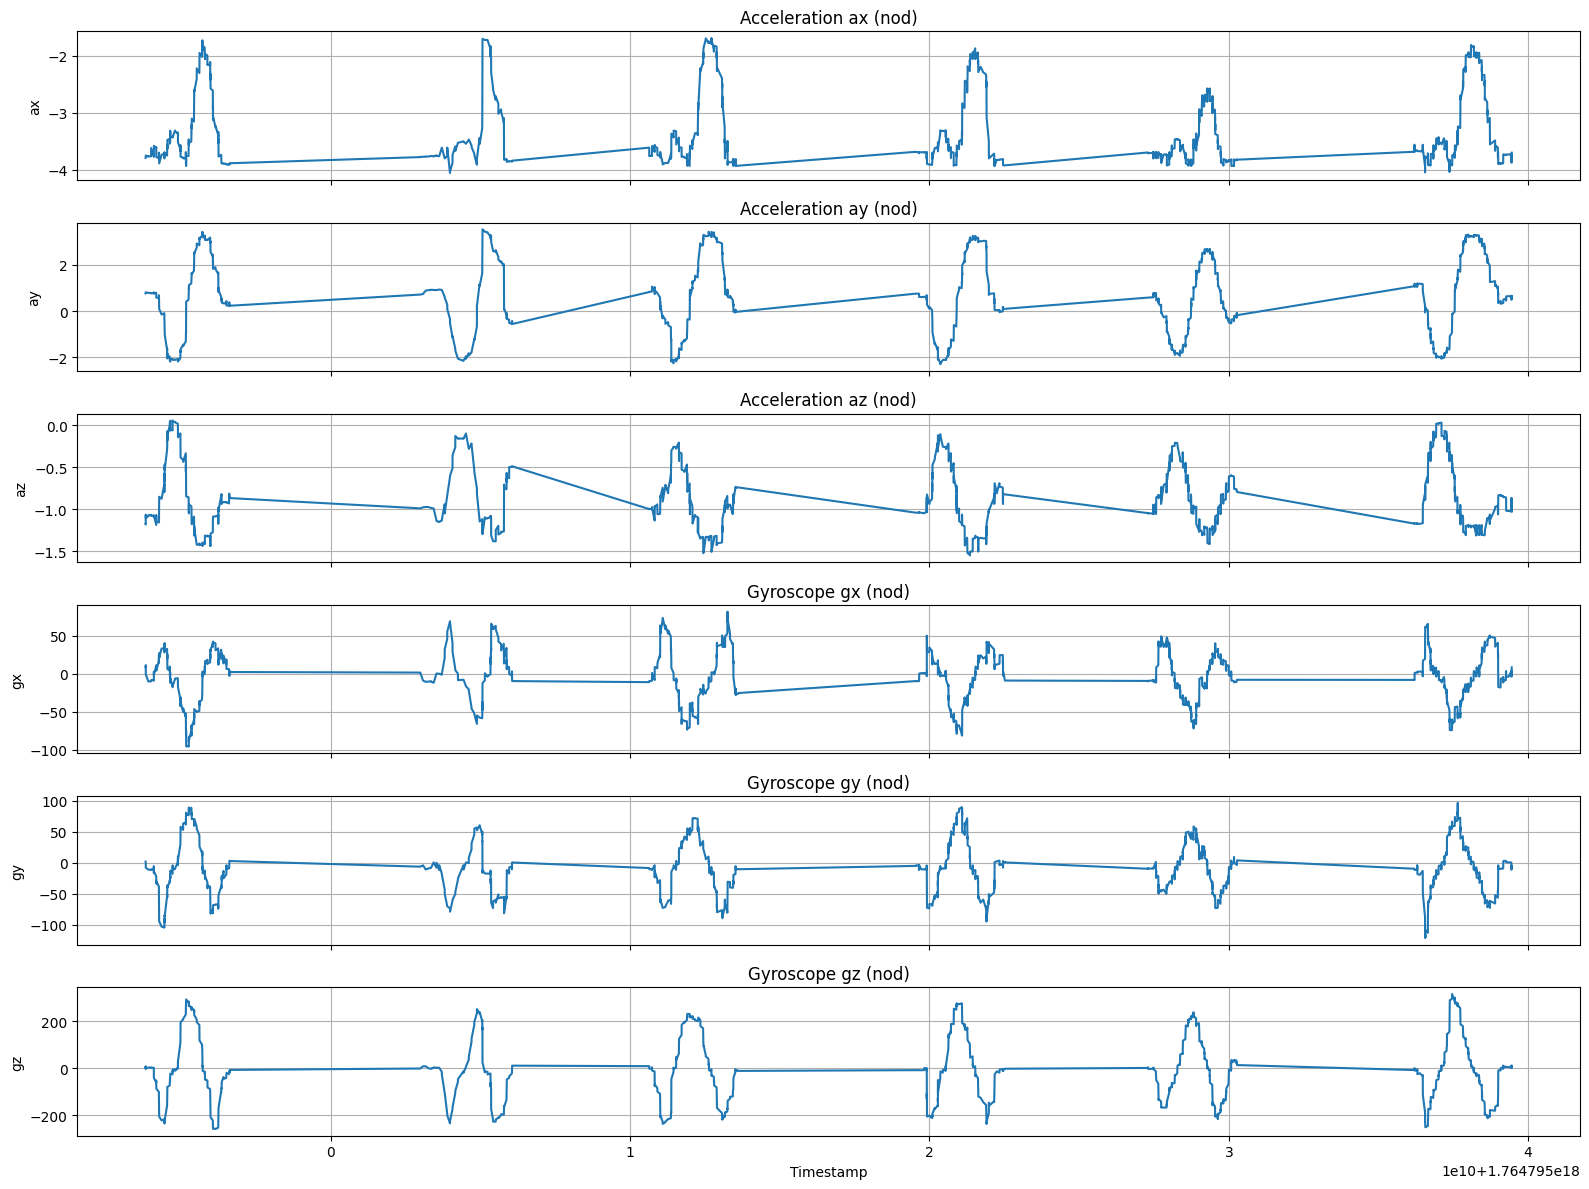

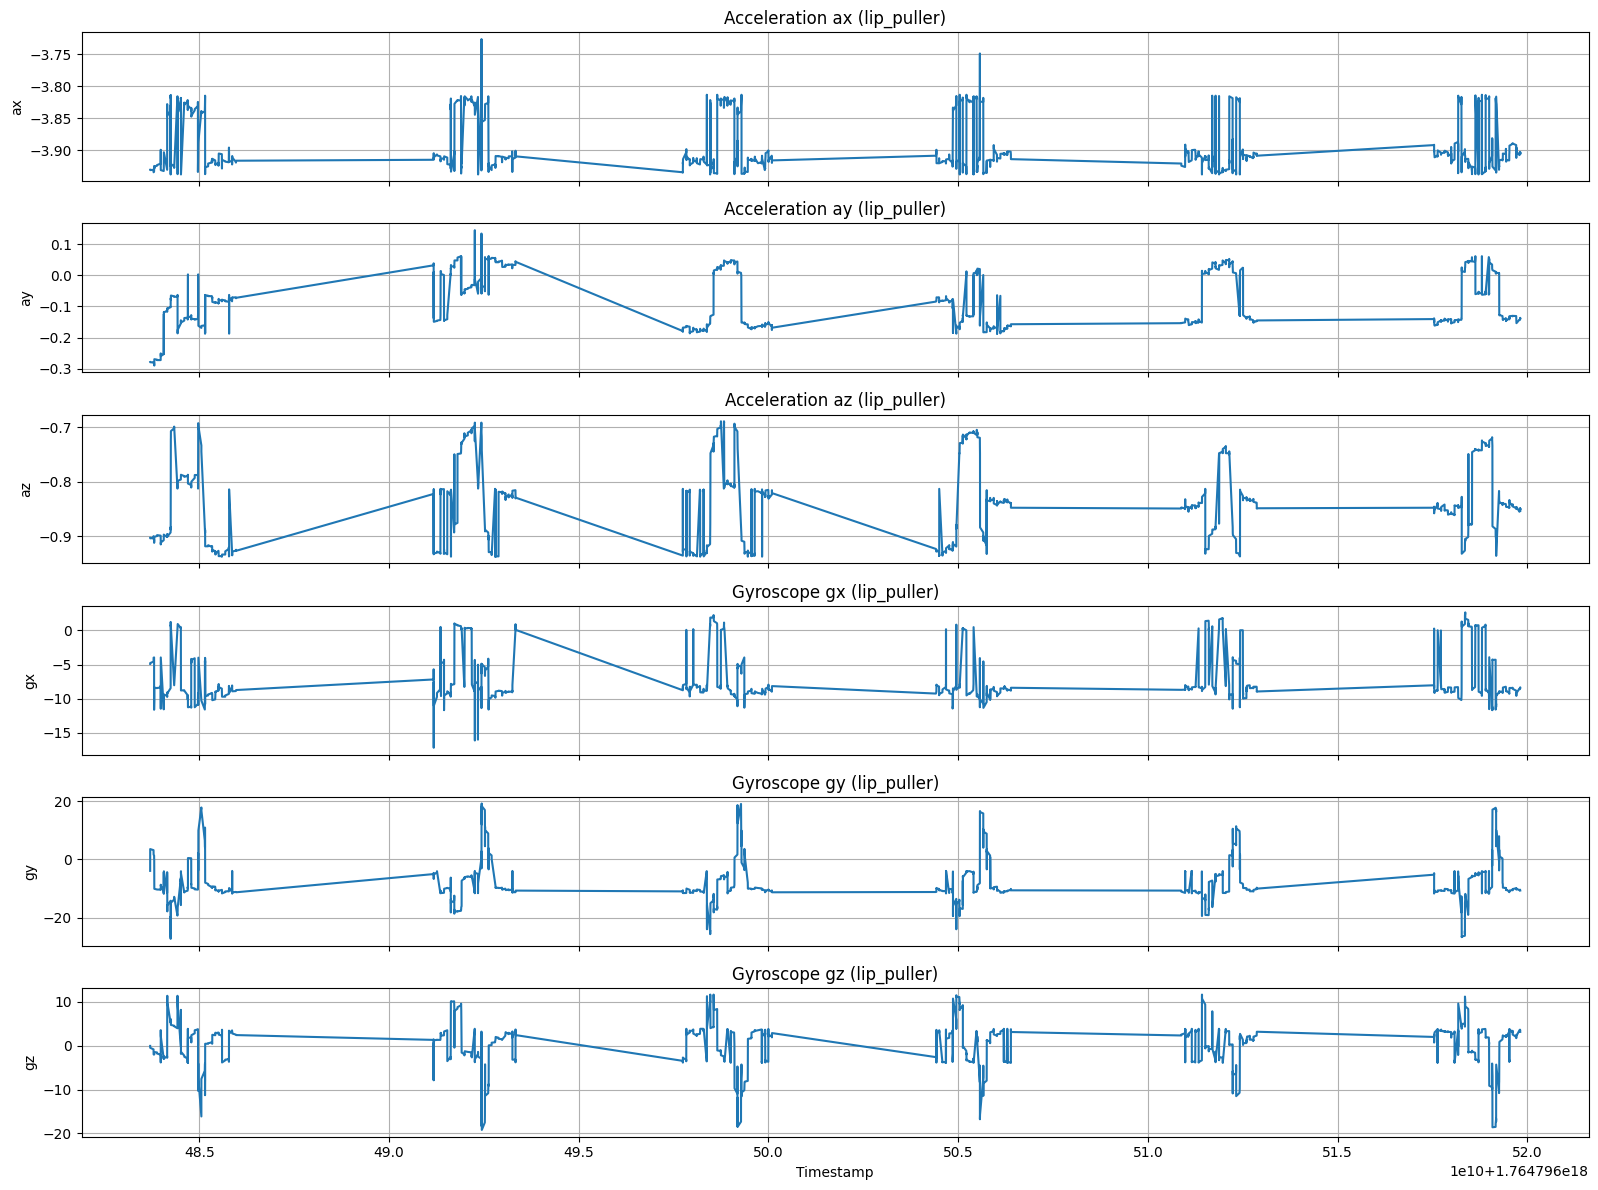

In [ ]:
# this frame is for plotting each imu gestures for each individual on the same plot
import matplotlib.pyplot as plt

def plot_all_imu_data(plot_list, participant_id, filename_to_plot):
  df = None
  for p_id, data_entries in plot_list.items():
    if p_id == participant_id:
      for d_frame, f_name in data_entries:
        if f_name == filename_to_plot:
          df = d_frame
          break
      if df is not None:
        break
  fig, axes = plt.subplots(6, 1, figsize=(16,12), sharex = True)

  accel_cols = ['ax', 'ay', 'az']
  gyro_cols = ['gx', 'gy', 'gz']
  all_cols = accel_cols + gyro_cols

  for i, col in enumerate(all_cols):
    # if col in accel_cols:
    #   continue
    axes[i].plot(df['timestamp'], df[col], label=col)
    axes[i].set_ylabel(col)
    axes[i].grid(True) # set it to false later to check what it does
    if col in accel_cols:
      axes[i].set_title(f'Acceleration {col} ({filename_to_plot})')
    else:
      axes[i].set_title(f'Gyroscope {col} ({filename_to_plot})')

  axes[-1].set_xlabel('Timestamp')
  plt.tight_layout()
  plt.show()



#call
plot_all_imu_data(section_dict_new, 5, "shake")
plot_all_imu_data(section_dict_new, 5, "tilt")
plot_all_imu_data(section_dict_new, 5, "nod")
plot_all_imu_data(section_dict_new, 5, "lip_puller")


In [ ]:
import numpy as np

def perform_fft(data_series, timestamp_series):
  time_diffs = np.diff(timestamp_series)
  sampling_rate = 1000 # we have assumed sampling rate over here, should we use the median technique to calculate it?
  fft_results = np.fft.fft(data_series)
  frequencies = np.fft.fftfreq(len(data_series), d=1.0/sampling_rate)
  return np.abs(fft_results), frequencies

# this functions returns the frequencies (X-axis) and their magnitudes (Y-axis)

## Apply fft to all dataframes




**Reasoning**:
Initialize dictionaries to store the frequency domain data for each participant list and iterate through the lists and dataframes to apply the FFT function to relevant columns.



In [ ]:
fft_results_dict = {}

for part_idx, data_list in section_dict_new.items():
  fft_results_dict[part_idx] = {}
  for df, filename in data_list:
    file_key = f'{filename}'
    fft_results_dict[part_idx][file_key] = {}
    for col in df.select_dtypes(include=np.number).columns:
      if col == 'timestamp':
        continue
      magnitudes, frequencies = perform_fft(df[col], df['timestamp'])
      fft_results_dict[part_idx][file_key][col] = {
          'magnitudes': magnitudes,
          'frequencies': frequencies
      }

# print(fft_results_dict)

# this portion of code performs fft on each df and then stores the result of in fft_results_dict

# Calculating merged features here

In [ ]:
template_gestures_ay = {}
participant_id = 2

for gesture_name in gestures:
    for df_data, name_in_dict in section_dict_new[participant_id]:
        if name_in_dict == gesture_name.lower():
            print(name_in_dict)
            template_gestures_ay[gesture_name] = df_data['ax'].values
            break

print("Template 'ay' data prepared for DTW:")
for gesture, data in template_gestures_ay.items():
    print(f"  {gesture}: {len(data)} data points")


shake
nod
tilt
lip_puller
Template 'ay' data prepared for DTW:
  SHAKE: 934 data points
  NOD: 559 data points
  TILT: 373 data points
  LIP_PULLER: 600 data points


In [ ]:
import numpy as np
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean

def compute_dtw_feature(input_df, gesture_type, template_gestures_ay):
    if gesture_type not in template_gestures_ay:
        print(f"Template for {gesture_type} not found.")
        return None

    template_series = np.array(template_gestures_ay[gesture_type]).flatten().astype(float)
    input_series = np.array(input_df['ax'].values).flatten().astype(float)
    distance, path = fastdtw(input_series, template_series)
    return distance


In [ ]:
def mean_crossing_rate(data_series):
  mean_value = np.mean(data_series)
  crossings = np.where(np.diff(np.sign(data_series - mean_value)))[0]
  mcr = len(crossings) / len(data_series)
  return mcr

def calculate_merged_features(df, filename):
  features = {}
  numeric_cols = df.select_dtypes(include=np.number).columns.drop('timestamp', errors='ignore')

  for col in numeric_cols:
    if (col == 'gy'):
      features[f'{col}_rms'] = np.sqrt(np.mean(df[col]**2))

  if len(numeric_cols) >= 3:
    corr_matrix = df[numeric_cols].corr()

    # Extract specific correlations
    if 'ax' in numeric_cols and 'ay' in numeric_cols:
      features['ax_ay_corr'] = corr_matrix.loc['ax','ay']
    # if 'ax' in numeric_cols and 'az' in numeric_cols:
    #   features['ax_az_corr'] = corr_matrix.loc['ax', 'az']
    if 'ay' in numeric_cols and 'az' in numeric_cols:
        features['ay_az_corr'] = corr_matrix.loc['ay', 'az']
    # if 'gx' in numeric_cols and 'gy' in numeric_cols:
    #     features['gx_gy_corr'] = corr_matrix.loc['gx', 'gy']
    if 'gx' in numeric_cols and 'gz' in numeric_cols:
        features['gx_gz_corr'] = corr_matrix.loc['gx', 'gz']
    if 'gy' in numeric_cols and 'gz' in numeric_cols:
        features['gy_gz_corr'] = corr_matrix.loc['gy', 'gz']

  features['ay_dtw_tilt'] = compute_dtw_feature(df, 'TILT', template_gestures_ay)


  time_diffs = np.diff(df['timestamp'])
  median_diff_sec = np.median(time_diffs) / 1000
  sampling_rate = 1/ median_diff_sec if median_diff_sec > 0 else 50


  features['classification_tag'] = filename
  return features

all_features_rows = []
for person_id, files in section_dict_new.items():
  for df, gesture_name in files:
    row_features = calculate_merged_features(df, gesture_name)
    row_features['person_id'] = person_id
    all_features_rows.append(row_features)

merged_df = pd.DataFrame(all_features_rows)
display(merged_df)

,gy_rms,ax_ay_corr,ay_az_corr,gx_gz_corr,gy_gz_corr,ay_dtw_tilt,classification_tag,person_id
0,34.650074,0.407676,0.074054,0.983823,-0.876143,178.743168,shake,0
1,50.335974,0.706399,-0.951489,-0.953539,0.983580,98.222164,nod,0
2,97.923608,-0.886604,0.923477,-0.799008,-0.928904,76.319819,tilt,0
3,11.236848,0.126872,0.025554,0.447654,-0.700424,238.388658,lip_puller,0
4,31.581539,0.466910,-0.032240,0.983186,-0.886214,187.611335,shake,1
5,47.208323,0.738921,-0.934814,-0.953447,0.981102,65.670411,nod,1
6,96.223441,-0.874097,0.910682,-0.793555,-0.910406,30.406250,tilt,1
7,10.833602,0.008682,0.273868,0.227604,-0.762571,245.898438,lip_puller,1
8,34.219729,0.461652,0.030634,0.983478,-0.892609,214.393070,shake,2
9,45.629075,0.759678,-0.944574,-0.945341,0.977920,92.399411,nod,2


Overall Accuracy: 1.0
Overall Classification Report:
              precision    recall  f1-score   support

  lip_puller       1.00      1.00      1.00        10
         nod       1.00      1.00      1.00        10
       shake       1.00      1.00      1.00        10
        tilt       1.00      1.00      1.00        10

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



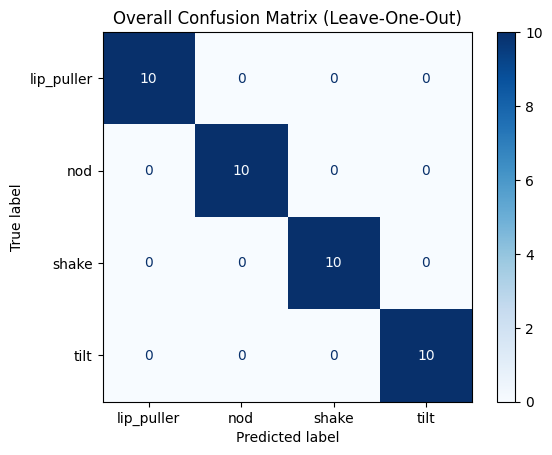

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import LeaveOneOut
import matplotlib.pyplot as plt


X = merged_df.drop(['classification_tag','person_id'], axis=1)
y = merged_df['classification_tag']

loo = LeaveOneOut()
y_true_all = []
y_pred_all = []
svm_model = SVC(kernel='linear')

for train_index, test_index in loo.split(X):
  X_train, X_test = X.iloc[train_index], X.iloc[test_index]
  y_train, y_test = y.iloc[train_index], y.iloc[test_index]

  scaler = StandardScaler()
  X_train = scaler.fit_transform(X_train)
  X_test  = scaler.transform(X_test)
  # print(X_train, y_train)

  svm_model.fit(X_train, y_train)

  y_pred = svm_model.predict(X_test)

  y_true_all.extend(y_test)
  y_pred_all.extend(y_pred)

accuracy = accuracy_score(y_true_all, y_pred_all)
print(f"Overall Accuracy: {accuracy}")
print("Overall Classification Report:")
print(classification_report(y_true_all, y_pred_all))

overall_cm = confusion_matrix(y_true_all, y_pred_all)
disp_overall = ConfusionMatrixDisplay(confusion_matrix=overall_cm, display_labels=svm_model.classes_)
disp_overall.plot(cmap=plt.cm.Blues)
plt.title('Overall Confusion Matrix (Leave-One-Out)')
plt.show()

In [ ]:
# Get the exact column order for the server
print("COPY THIS LIST EXACTLY:")
print(X.columns.tolist())

COPY THIS LIST EXACTLY:
['gy_rms', 'ax_ay_corr', 'ay_az_corr', 'gx_gz_corr', 'gy_gz_corr', 'ay_dtw_tilt']


## Save the model for Flask server

In [ ]:
import joblib

#Saving the model
joblib.dump(svm_model, 'gesture_svm.pkl')

#Saving the fitted scaler so that the raw sensor data makes sense to the app
joblib.dump(scaler, 'gesture_scaler.pkl')
joblib.dump(template_gestures_ay, 'template_gestures.pkl')

print("Brain of the model saved!")

Brain of the model saved!


In [ ]:
!ngrok authtoken 36LxdsJ0GJD5fOfZmzYWYYHxyAj_5WYZyu5VNcUK94o8kryGN

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
%%writefile server.py
import pandas as pd
import numpy as np
from scipy.stats import iqr
from flask import Flask, request, jsonify
import joblib

app = Flask(__name__)

#Loading the saved brain of the model
model = joblib.load('gesture_svm.pkl')
scaler = joblib.load('gesture_scaler.pkl')
template_gestures_ay = joblib.load('template_gestures.pkl')

TRAINING_COLUMNS = ['gy_rms', 'ax_ay_corr', 'ay_az_corr', 'gx_gz_corr', 'gy_gz_corr', 'ay_dtw_tilt']

import numpy as np
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean # Keep import for reference, but won't be passed directly

def compute_dtw_feature(input_df, gesture_type, template_gestures_ay):
    if gesture_type not in template_gestures_ay:
        print(f"Template for {gesture_type} not found.")
        return None

    # Ensure template_series is a 1-D numpy array of floats
    template_series = np.array(template_gestures_ay[gesture_type]).flatten().astype(float)
    # Ensure input_series is a 1-D numpy array of floats
    input_series = np.array(input_df['ay'].values).flatten().astype(float)
    distance, path = fastdtw(input_series, template_series)
    return distance


def scale_columns(df):
  for col in df.columns:
    if col.startswith('time'):
      df[col] = df[col].astype(np.int64)
  return df

def mean_crossing_rate(data_series):
  mean_value = np.mean(data_series)
  crossings = np.where(np.diff(np.sign(data_series - mean_value)))[0]
  mcr = len(crossings) / len(data_series)
  return mcr

def calculate_merged_features(df):
  features = {}
  numeric_cols = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']

  for col in numeric_cols:
    if col not in df.columns: df[col] = 0.0

  for col in numeric_cols:
    if col == 'gy':
      features[f'{col}_rms'] = np.sqrt(np.mean(df[col]**2))
  #     features[f'{col}_mean_crossing_rate'] = mean_crossing_rate(df[col])

  if len(numeric_cols) >= 3:
    corr_matrix = df[numeric_cols].corr()
    pairs = [('ax', 'ay'), ('ay','az'), ('gx','gz'), ('gy','gz')]
    for c1, c2 in pairs:
      features[f'{c1}_{c2}_corr'] = corr_matrix.loc[c1, c2] if not corr_matrix.empty else 0
  features['ay_dtw_tilt'] = compute_dtw_feature(df, 'TILT', template_gestures_ay)

  return features


@app.route('/predict', methods=['POST'])
def predict():
  try:
    json_data = request.json
    df = pd.DataFrame(json_data)

    df = scale_columns(df)

    features_dict = calculate_merged_features(df)

    features_df = pd.DataFrame([features_dict])

    # Ensure columns match training
    features_df = features_df.reindex(columns=TRAINING_COLUMNS, fill_value=0)

    features_scaled = scaler.transform(features_df)

    prediction = model.predict(features_scaled)[0]

    return jsonify({'gesture': prediction, 'status': 'success'})

  except Exception as e:
    return jsonify({'error': str(e), 'status': 'fail'})


@app.route('/predict_dtw', methods=['POST'])
def predict():
  try:
    json_data = request.json
    df = pd.DataFrame(json_data)

    df = scale_columns(df)

    features_dict = calculate_merged_features(df)

    features_df = pd.DataFrame([features_dict])

    # Ensure columns match training
    features_df = features_df.reindex(columns=TRAINING_COLUMNS, fill_value=0)

    features_scaled = scaler.transform(features_df)

    prediction = model.predict(features_scaled)[0]

    return jsonify({'gesture': prediction, 'status': 'success'})

  except Exception as e:
    return jsonify({'error': str(e), 'status': 'fail'})

@app.route('/status', methods=['GET'])
def status():
  return jsonify({'status': 'success'})

if __name__ == '__main__':
  app.run(port=5000)

Writing server.py


In [ ]:
import subprocess
import sys
import os
from pyngrok import ngrok


# Terminate open tunnels

try:
    ngrok.kill()
    print("Killed old ngrok connection previously started")

    # Open an HTTP tunnel on the default port 5000

    print("Attempting to stop old server...")
    # 1. Kill old server
    # check=False means it won't crash if there is no server currently running
    subprocess.run(["pkill", "-f", "server.py"], check=False)

    print("Verifying server file...")
    # 2. Safety Check: Ensure server.py actually exists
    if not os.path.exists("server.py"):
        raise FileNotFoundError("server.py not found! Did you run the '%%writefile' cell?")

    print("Starting new server...")
    # 3. Start new server
    # sys.executable ensures we use the correct Python environment
    process = subprocess.Popen([sys.executable, "server.py"])

    print(f"✅ Server restarted successfully! (PID: {process.pid})")
    public_url = ngrok.connect(5000)
    print(f"🚀 YOUR PUBLIC URL: {public_url}")

except Exception as e:
    print(f"❌ CRASH: Failed to restart server.\nError: {e}")

Killed old ngrok connection previously started
Attempting to stop old server...
Verifying server file...
Starting new server...
✅ Server restarted successfully! (PID: 1510)
🚀 YOUR PUBLIC URL: NgrokTunnel: "https://postpaludal-prayerful-temeka.ngrok-free.dev" -> "http://localhost:5000"
